# Stage 4 - RL Policy Evaluation vs Baselines

Compares the Stage 4 neural RL policy against fixed baselines and adds a rollout-context comparison between training rollouts and evaluation rollouts.

| Dimension | Source | Metric |
|-----------|--------|--------|
| **Reward convergence** | `per_episode_*.csv` | `episode_return` per episode |
| **Policy stability** | `per_episode_*.csv` | `action_variance` per episode |
| **Baseline comparison** | `per_step_*.csv` + `inference_eval_*.csv` | GPU/FPS/LOD behavior |
| **Statistical testing** | episode means when available, else per-step GPU | Welch t-test + 95% CI |
| **Rollout context** | `RL/Train/RLRollouts` vs `RL/Eval/RLRollouts` | action, GPU, and bias distributions |

**Per-step data** (`per_step_*.csv`): produced by `RLEvaluationLogger` in `RL/Eval/RL_Eval`  
**Per-episode data** (`per_episode_*.csv`): produced by `RLEvaluationLogger` in `RL/Eval/RL_Eval`  
**Baseline data** (`inference_eval_*.csv`): from `data/BaseLine/`

### Expected run labels
- `neural_rl_bootstrap_v1` - Stage 4 ONNX model assigned  
- `fixed_default` - fixed `lodBias = 1.0` baseline  
- `fixed_aggressive` - fixed lower-bias baseline

### Important note
- RL KPI = GPU time against the 4.5 ms target.
- 16.67 ms remains a CPU diagnostic only; it is not the RL success threshold.
- Legacy baselines loaded from `data/BaseLine/` remain provisional until they are re-recorded with `RLEvaluationLogger` on matching paths.


In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_style('darkgrid')
print('Libraries OK')

Libraries OK


In [4]:
BASE_DIR          = Path('../..').resolve()
RL_ROOT           = BASE_DIR / 'data' / 'RL'
EVAL_DIR          = RL_ROOT / 'Eval' / 'RL_Eval'
EVAL_ROLLOUT_DIR  = RL_ROOT / 'Eval' / 'RLRollouts'
TRAIN_ROLLOUT_DIR = RL_ROOT / 'Train' / 'RLRollouts'
BASELINE_DIR      = BASE_DIR / 'data' / 'BaseLine'
PLOTS_DIR         = BASE_DIR / 'plots' / 'Stage_4' / 'Eval'

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Load T_TARGET from training scaler for consistency
import json
scaler_path = BASE_DIR / "models" / "Stage_4" /"Perfected" / "rl_scaler_constants.json"
with open(scaler_path, "r") as f:
    scaler_data = json.load(f)
GPU_TARGET_MS = scaler_data.get("t_target_ms", 4.5)  # Loaded from training scaler
CPU_FRAME_BUDGET_MS = 16.67
T_TARGET_MS = GPU_TARGET_MS
FRAME_BUDGET_MS = CPU_FRAME_BUDGET_MS
MODEL_LABEL = 'neural_rl_bootstrap_v1'

MIN_EPISODE_FRAMES = 100

RUN_COLORS = {
    'neural_rl_bootstrap_v1': '#2196F3',
    'fixed_default': '#4CAF50',
    'fixed_aggressive': '#FF9800',
    'train_rollout': '#9C27B0',
    'eval_rollout': '#795548',
}
DEFAULT_COLOR = '#607D8B'

print(f'EVAL_DIR             : {EVAL_DIR}')
print(f'EVAL_ROLLOUT_DIR     : {EVAL_ROLLOUT_DIR}')
print(f'TRAIN_ROLLOUT_DIR    : {TRAIN_ROLLOUT_DIR}')
print(f'BASELINE_DIR         : {BASELINE_DIR}')
print(f'PLOTS_DIR            : {PLOTS_DIR}')
print(f'MODEL_LABEL          : {MODEL_LABEL}')
print(f'GPU_TARGET_MS        : {GPU_TARGET_MS}')
print(f'CPU_FRAME_BUDGET_MS  : {CPU_FRAME_BUDGET_MS}')
print(f'MIN_EPISODE_FRAMES   : {MIN_EPISODE_FRAMES}')


EVAL_DIR             : C:\Users\Gica\neural-lod\ml_pipeline\data\RL\Eval\RL_Eval
EVAL_ROLLOUT_DIR     : C:\Users\Gica\neural-lod\ml_pipeline\data\RL\Eval\RLRollouts
TRAIN_ROLLOUT_DIR    : C:\Users\Gica\neural-lod\ml_pipeline\data\RL\Train\RLRollouts
BASELINE_DIR         : C:\Users\Gica\neural-lod\ml_pipeline\data\BaseLine
PLOTS_DIR            : C:\Users\Gica\neural-lod\ml_pipeline\plots\Stage_4\Eval
MODEL_LABEL          : neural_rl_bootstrap_v1
GPU_TARGET_MS        : 5.0
CPU_FRAME_BUDGET_MS  : 16.67
MIN_EPISODE_FRAMES   : 100


## 1. Load Per-Step Data
Reads `per_step_*.csv` from `data/RL/Eval/RL_Eval/` and fixed baselines from `data/BaseLine/`.


In [5]:
step_files_rl   = list(EVAL_DIR.glob('per_step_*.csv'))
step_files_base = list(BASELINE_DIR.glob('inference_eval_*.csv'))

print(f'RL per-step files  : {len(step_files_rl)}')
print(f'Baseline eval files: {len(step_files_base)}')

dfs = []

for f in step_files_rl:
    df = pd.read_csv(f)
    df['source'] = 'rl'
    dfs.append(df)

for f in step_files_base:
    df = pd.read_csv(f)
    rename = {
        'cpu_frame_time': 'cpu_ms',
        'gpu_frame_time': 'gpu_ms',
        'lod_bias_applied': 'lod_bias'
    }
    df = df.rename(columns=rename)
    if 'run_label' not in df.columns:
        df['run_label'] = f.stem
    if 'episode' not in df.columns:
        df['episode'] = 0
    if 'action_delta' not in df.columns:
        df['action_delta'] = 0.0
    if 'reward_step' not in df.columns:
        df['reward_step'] = 0.0
    if 'cumulative_return' not in df.columns:
        df['cumulative_return'] = 0.0
    if 'screen_coverage' not in df.columns:
        df['screen_coverage'] = 0.0
    if 'screen_coverage_delta' not in df.columns:
        df['screen_coverage_delta'] = 0.0
    if 'recent_switch_count' not in df.columns:
        df['recent_switch_count'] = 0.0
    df['source'] = 'baseline'
    dfs.append(df)

if not dfs:
    raise FileNotFoundError('No eval CSVs found in RL/Eval/RL_Eval or BaseLine.')

data = pd.concat(dfs, ignore_index=True)

numeric_cols = ['episode', 'frame', 'cpu_ms', 'gpu_ms', 'fps', 'lod_bias',
                'action_delta', 'reward_step', 'cumulative_return',
                'screen_coverage', 'recent_switch_count']
for col in numeric_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna(subset=['cpu_ms', 'gpu_ms', 'fps'])

preferred_runs = [MODEL_LABEL, 'fixed_default', 'fixed_aggressive']
runs = [r for r in preferred_runs if r in data['run_label'].unique()]
extra_runs = [r for r in sorted(data['run_label'].unique()) if r not in runs]
runs = runs + extra_runs

print(f'Run labels: {runs}')
print(f'Total rows: {len(data):,}')
print()
print(data.groupby('run_label').size().rename('frames'))


RL per-step files  : 2
Baseline eval files: 2
Run labels: ['neural_rl_bootstrap_v1', 'fixed_default', 'fixed_aggressive', 'neural_rl_held_out']
Total rows: 17,743

run_label
fixed_aggressive          4225
fixed_default             3914
neural_rl_bootstrap_v1    4556
neural_rl_held_out        5048
Name: frames, dtype: int64


## 2. Load Per-Episode Data
Reads `per_episode_*.csv` from `data/RL/Eval/RL_Eval/` for reward convergence and stability metrics.


In [6]:
ep_files = list(EVAL_DIR.glob('per_episode_*.csv'))
print(f'Per-episode files: {len(ep_files)}')

ep_dfs = []
for f in ep_files:
    df = pd.read_csv(f)
    ep_dfs.append(df)

if ep_dfs:
    ep_data_raw = pd.concat(ep_dfs, ignore_index=True)
    for col in ['episode', 'total_frames', 'episode_return', 'mean_gpu_ms',
                'action_mean', 'action_variance', 'switch_count_total']:
        if col in ep_data_raw.columns:
            ep_data_raw[col] = pd.to_numeric(ep_data_raw[col], errors='coerce')

    # Filter out very short episodes -- these are segmentation artefacts where the
    # episode boundary in RLEvaluationLogger fired before a full episode elapsed.
    # They produce unreliable episode_return and action_variance statistics.
    # Per-step metrics (GPU time, FPS) are unaffected because they use the step-level CSVs.
    if 'total_frames' in ep_data_raw.columns:
        n_before = len(ep_data_raw)
        short_eps = ep_data_raw[ep_data_raw['total_frames'] < MIN_EPISODE_FRAMES]
        ep_data   = ep_data_raw[ep_data_raw['total_frames'] >= MIN_EPISODE_FRAMES].copy()
        n_dropped = n_before - len(ep_data)
        if n_dropped > 0:
            print(f'Dropped {n_dropped} short episodes (< {MIN_EPISODE_FRAMES} frames):')
            for _, row in short_eps.iterrows():
                run = row.get('run_label', 'unknown')
                ep  = row.get('episode', '?')
                fr  = row.get('total_frames', '?')
                print(f'  run={run}  episode={ep}  total_frames={fr}')
            print(f'Retained {len(ep_data)} episodes for episode-level analysis.')
        else:
            ep_data = ep_data_raw
    else:
        ep_data = ep_data_raw

    ep_runs = sorted(ep_data['run_label'].unique())
    print(f'Episode-level runs: {ep_runs}')
    print(f'Total episodes    : {len(ep_data)}')
    display(ep_data.head(5))
else:
    ep_data = None
    print('No per_episode_*.csv found. Reward convergence and stability plots will be skipped.')

Per-episode files: 2
Episode-level runs: ['neural_rl_bootstrap_v1', 'neural_rl_held_out']
Total episodes    : 13


,run_label,episode,total_frames,episode_return,mean_gpu_ms,mean_fps,mean_lod_bias,action_mean,action_variance,switch_count_total,target_start_ms,target_end_ms,target_source_start,target_source_end,scene_target_ready_end
0,neural_rl_bootstrap_v1,0,1024,57.689590,7.0837,73.15,0.3967,0.000948,0.000369,20,5.0,5.0,json_training,json_training,0
1,neural_rl_bootstrap_v1,1,1024,186.220100,6.1125,63.46,0.6140,-0.000946,0.001160,56,5.0,5.0,json_training,json_training,0
2,neural_rl_bootstrap_v1,2,317,0.758784,6.0459,71.16,0.3109,0.000000,0.000000,0,5.0,5.0,json_training,json_training,0
3,neural_rl_bootstrap_v1,3,1024,85.255580,6.0235,58.13,0.5401,-0.000657,0.001488,86,5.0,5.0,json_training,json_training,0
4,neural_rl_bootstrap_v1,4,1024,189.899200,5.7088,51.72,0.5640,0.001012,0.000509,31,5.0,5.0,json_training,json_training,0


## 3. Performance Summary Matrix

In [7]:
def pct(series, p):
    series = series.dropna()
    if len(series) == 0:
        return float('nan')
    return float(np.percentile(series, p))

rows = []
for run in runs:
    df = data[data['run_label'] == run]
    cpu = df['cpu_ms'].dropna()
    gpu = df['gpu_ms'].dropna()
    fps = df['fps'].dropna()
    act = df['action_delta'].dropna()
    lod = df['lod_bias'].dropna()

    lod_vals = lod.values
    switches = sum(
        1 for i in range(1, len(lod_vals))
        if abs(lod_vals[i] - lod_vals[i - 1]) > 0.001
    )
    dur_s = len(df) / fps.mean() if len(fps) and fps.mean() > 0 else np.nan
    flip_rate = switches / dur_s if dur_s and dur_s > 0 else np.nan

    rows.append({
        'run_label': run,
        'frames': len(df),
        'mean_cpu_ms': round(cpu.mean(), 3) if len(cpu) else np.nan,
        'p95_cpu_ms': round(pct(cpu, 95), 3),
        'p99_cpu_ms': round(pct(cpu, 99), 3),
        'mean_gpu_ms': round(gpu.mean(), 3) if len(gpu) else np.nan,
        'p95_gpu_ms': round(pct(gpu, 95), 3),
        'p99_gpu_ms': round(pct(gpu, 99), 3),
        'gpu_over_target_pct': round(100 * (gpu > GPU_TARGET_MS).sum() / len(gpu), 1) if len(gpu) else np.nan,
        'cpu_over_budget_pct': round(100 * (cpu > CPU_FRAME_BUDGET_MS).sum() / len(cpu), 1) if len(cpu) else np.nan,
        'mean_fps': round(fps.mean(), 2) if len(fps) else np.nan,
        'p5_fps': round(pct(fps, 5), 2),
        'mean_lod_bias': round(lod.mean(), 4) if len(lod) else np.nan,
        'action_std': round(act.std(), 4) if len(act) else np.nan,
        'lod_switches': switches,
        'flip_rate_hz': round(flip_rate, 3) if pd.notna(flip_rate) else np.nan,
        'mean_screen_cov': round(df['screen_coverage'].dropna().mean(), 4)
            if 'screen_coverage' in df.columns and len(df['screen_coverage'].dropna()) else np.nan,
    })

summary = pd.DataFrame(rows).set_index('run_label')
print('=== Performance Summary ===')
display(summary.T)


=== Performance Summary ===


run_label,neural_rl_bootstrap_v1,fixed_default,fixed_aggressive,neural_rl_held_out
frames,4556.0000,3914.000,4225.000,5048.0000
mean_cpu_ms,24.5090,16.666,16.666,24.3780
p95_cpu_ms,36.1510,17.048,17.032,35.6090
p99_cpu_ms,39.4980,17.390,17.250,36.9260
mean_gpu_ms,5.6070,5.218,4.683,5.7250
p95_gpu_ms,8.6300,6.402,5.657,8.3570
p99_gpu_ms,9.8080,6.761,6.021,9.4150
gpu_over_target_pct,78.1000,58.500,31.600,80.7000
cpu_over_budget_pct,85.5000,49.800,49.100,86.2000
mean_fps,61.6100,60.000,60.000,66.3900


## 4. Reward Convergence (RL Metric 1)
Episode return per episode for RL runs. A converging policy shows increasing or stabilizing returns.

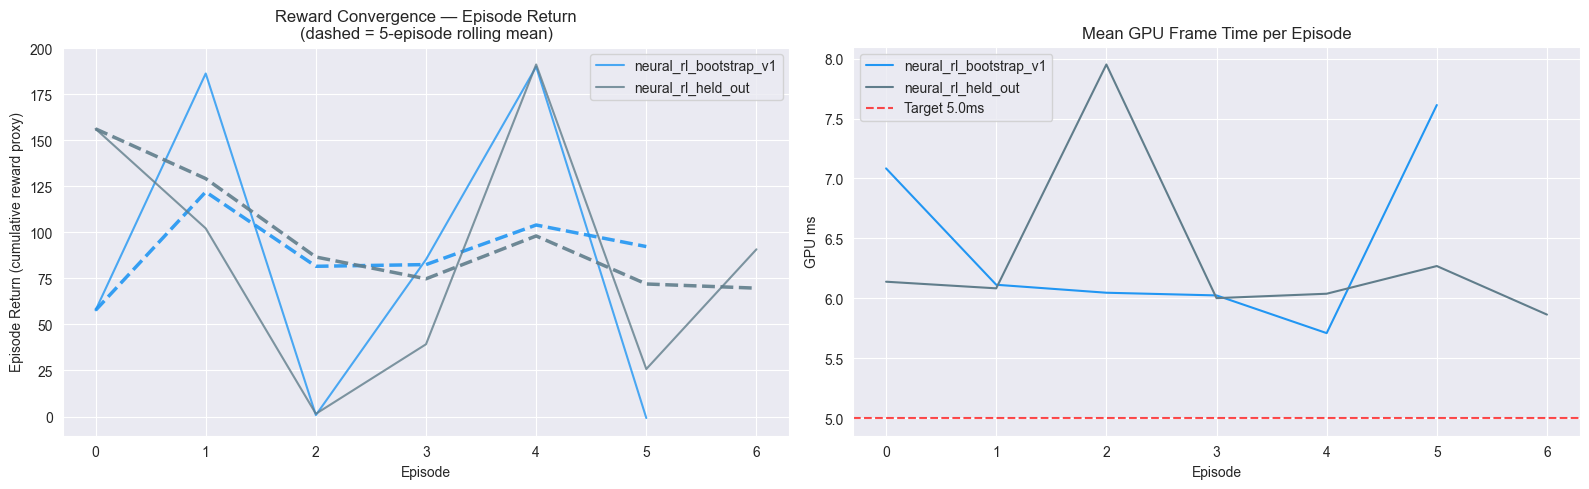


===== TRAINING SUMMARY =====

RUN: neural_rl_bootstrap_v1
  mean_return     = 86.498
  std_return      = 85.376
  trend (last-first) = 0.000
  mean_gpu_ms     = 6.431
  % over target   = 100.0%
  ❌ NO IMPROVEMENT

RUN: neural_rl_held_out
  mean_return     = 86.668
  std_return      = 69.776
  trend (last-first) = 0.000
  mean_gpu_ms     = 6.335
  % over target   = 100.0%
  ❌ NO IMPROVEMENT


In [8]:
if ep_data is None:
    print('Skipped — no per_episode_*.csv found.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Episode return per episode
    ax = axes[0]
    for run in ep_data['run_label'].unique():
        df_ep = ep_data[ep_data['run_label'] == run].sort_values('episode')
        color = RUN_COLORS.get(run, DEFAULT_COLOR)
        ax.plot(df_ep['episode'], df_ep['episode_return'],
                label=run, color=color, lw=1.5, alpha=0.8)
        # Rolling mean
        if len(df_ep) >= 5:
            roll = df_ep['episode_return'].rolling(5, min_periods=1).mean()
            ax.plot(df_ep['episode'], roll,
                    color=color, lw=2.5, linestyle='--', alpha=0.9)
    ax.set_title('Reward Convergence — Episode Return\n(dashed = 5-episode rolling mean)')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Episode Return (cumulative reward proxy)')
    ax.legend()

    # Mean GPU per episode
    ax = axes[1]
    for run in ep_data['run_label'].unique():
        df_ep = ep_data[ep_data['run_label'] == run].sort_values('episode')
        if 'mean_gpu_ms' in df_ep.columns:
            ax.plot(df_ep['episode'], df_ep['mean_gpu_ms'],
                    label=run, color=RUN_COLORS.get(run, DEFAULT_COLOR), lw=1.5)
    ax.axhline(T_TARGET_MS, color='red', linestyle='--', alpha=0.7,
               label=f'Target {T_TARGET_MS}ms')
    ax.set_title('Mean GPU Frame Time per Episode')
    ax.set_xlabel('Episode')
    ax.set_ylabel('GPU ms')
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'reward_convergence.png', dpi=150)
    plt.show()

    # ===== TEXT SUMMARY =====
print('\n===== TRAINING SUMMARY =====')

for run in ep_data['run_label'].unique():
    df_ep = ep_data[ep_data['run_label'] == run].sort_values('episode')

    returns = df_ep['episode_return'].dropna()
    mean_ret = returns.mean()
    std_ret = returns.std()

    trend = returns.tail(5).mean() - returns.head(5).mean() if len(returns) >= 10 else 0

    print(f'\nRUN: {run}')
    print(f'  mean_return     = {mean_ret:.3f}')
    print(f'  std_return      = {std_ret:.3f}')
    print(f'  trend (last-first) = {trend:.3f}')

    if 'mean_gpu_ms' in df_ep.columns:
        gpu = df_ep['mean_gpu_ms'].dropna()
        mean_gpu = gpu.mean()
        over_target = (gpu > T_TARGET_MS).mean() * 100

        print(f'  mean_gpu_ms     = {mean_gpu:.3f}')
        print(f'  % over target   = {over_target:.1f}%')

    # Simple flags
    if mean_ret < 0:
        print('  ❌ NEGATIVE PERFORMANCE')
    if std_ret > abs(mean_ret):
        print('  ❌ HIGH VARIANCE (unstable)')
    if trend <= 0:
        print('  ❌ NO IMPROVEMENT')

## 5. Policy Stability (RL Metric 2)
Action variance per episode. A stable policy converges to low variance — large variance = oscillation.

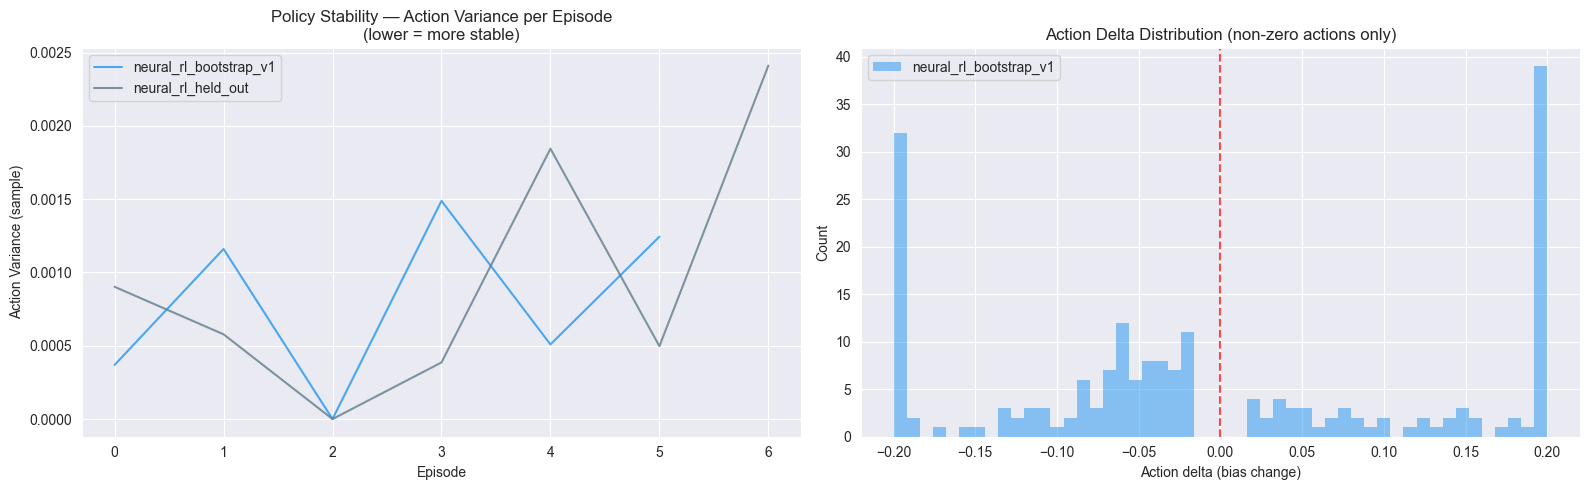

Stability summary:


,mean_action_variance,mean_return,std_return
run,,,
neural_rl_bootstrap_v1,0.000795,86.4985,85.3763
neural_rl_held_out,0.000945,86.6682,69.7761



===== STABILITY ANALYSIS =====

RUN: neural_rl_bootstrap_v1
  mean_action_variance = 0.000795
  mean_return          = 86.498
  std_return           = 85.376
  trend                = 0.000
  ✅ STABLE POLICY
  ❌ NO LEARNING PROGRESS
  action_bias (+/-)   = 40.5% / 59.5%

RUN: neural_rl_held_out
  mean_action_variance = 0.000945
  mean_return          = 86.668
  std_return           = 69.776
  trend                = 0.000
  ✅ STABLE POLICY
  ❌ NO LEARNING PROGRESS
  action_bias (+/-)   = 40.5% / 59.5%


In [9]:
if ep_data is None:
    print('Skipped — no per_episode_*.csv found.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Action variance per episode
    ax = axes[0]
    for run in ep_data['run_label'].unique():
        df_ep = ep_data[ep_data['run_label'] == run].sort_values('episode')
        if 'action_variance' in df_ep.columns:
            color = RUN_COLORS.get(run, DEFAULT_COLOR)
            ax.plot(df_ep['episode'], df_ep['action_variance'],
                    label=run, color=color, lw=1.5, alpha=0.8)
    ax.set_title('Policy Stability — Action Variance per Episode\n(lower = more stable)')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Action Variance (sample)')
    ax.legend()

    # Action delta distribution per run (per-step)
    ax = axes[1]
    rl_runs_in_step = [r for r in runs if r in [MODEL_LABEL]]
    for run in rl_runs_in_step:
        subset = data[(data['run_label'] == run) & (data['action_delta'] != 0)]['action_delta']
        if len(subset) > 0:
            ax.hist(subset, bins=50, alpha=0.5,
                    color=RUN_COLORS.get(run, DEFAULT_COLOR), label=run, edgecolor='none')
    ax.axvline(0, color='red', linestyle='--', alpha=0.7)
    ax.set_title('Action Delta Distribution (non-zero actions only)')
    ax.set_xlabel('Action delta (bias change)')
    ax.set_ylabel('Count')
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'policy_stability.png', dpi=150)
    plt.show()

    # Stability summary table
    stab_rows = []
    for run in ep_data['run_label'].unique():
        df_ep = ep_data[ep_data['run_label'] == run]
        stab_rows.append({
            'run': run,
            'mean_action_variance': round(df_ep['action_variance'].mean(), 6)
                if 'action_variance' in df_ep.columns else 'N/A',
            'mean_return': round(df_ep['episode_return'].mean(), 4)
                if 'episode_return' in df_ep.columns else 'N/A',
            'std_return': round(df_ep['episode_return'].std(), 4)
                if 'episode_return' in df_ep.columns else 'N/A',
        })
    stab_df = pd.DataFrame(stab_rows).set_index('run')
    print('Stability summary:')
    display(stab_df)


    # ===== STABILITY TEXT SUMMARY =====
print('\n===== STABILITY ANALYSIS =====')

for run in ep_data['run_label'].unique():
    df_ep = ep_data[ep_data['run_label'] == run].sort_values('episode')

    var  = df_ep['action_variance'].dropna() if 'action_variance' in df_ep.columns else pd.Series()
    ret  = df_ep['episode_return'].dropna() if 'episode_return' in df_ep.columns else pd.Series()

    mean_var = var.mean() if len(var) else 0
    mean_ret = ret.mean() if len(ret) else 0
    std_ret  = ret.std()  if len(ret) else 0

    # trend
    trend = ret.tail(5).mean() - ret.head(5).mean() if len(ret) >= 10 else 0

    print(f'\nRUN: {run}')
    print(f'  mean_action_variance = {mean_var:.6f}')
    print(f'  mean_return          = {mean_ret:.3f}')
    print(f'  std_return           = {std_ret:.3f}')
    print(f'  trend                = {trend:.3f}')

    # ===== FLAGS =====
    if mean_var < 1e-5:
        print('  ⚠️ POLICY COLLAPSE (near-zero variance)')

    elif mean_var < 1e-4:
        print('  ⚠️ VERY LOW EXPLORATION')

    elif mean_var > 1e-2:
        print('  ❌ HIGH INSTABILITY (oscillating policy)')

    else:
        print('  ✅ STABLE POLICY')

    if mean_ret < 0:
        print('  ❌ NEGATIVE REWARD')

    if std_ret > abs(mean_ret):
        print('  ❌ HIGH RETURN VARIANCE')

    if trend <= 0:
        print('  ❌ NO LEARNING PROGRESS')

    if mean_ret > 0 and trend > 0:
        print('  ✅ LEARNING SUCCESS')

    # ===== ACTION DISTRIBUTION CHECK =====
    if run in runs:
        subset = data[(data['run_label'] == run) & (data['action_delta'] != 0)]['action_delta']
        if len(subset) > 0:
            pos = (subset > 0).mean() * 100
            neg = (subset < 0).mean() * 100

            print(f'  action_bias (+/-)   = {pos:.1f}% / {neg:.1f}%')

            if pos > 90 or neg > 90:
                print('  ⚠️ STRONG ACTION BIAS (unbalanced policy)')


## 6. GPU Frame Time Comparison

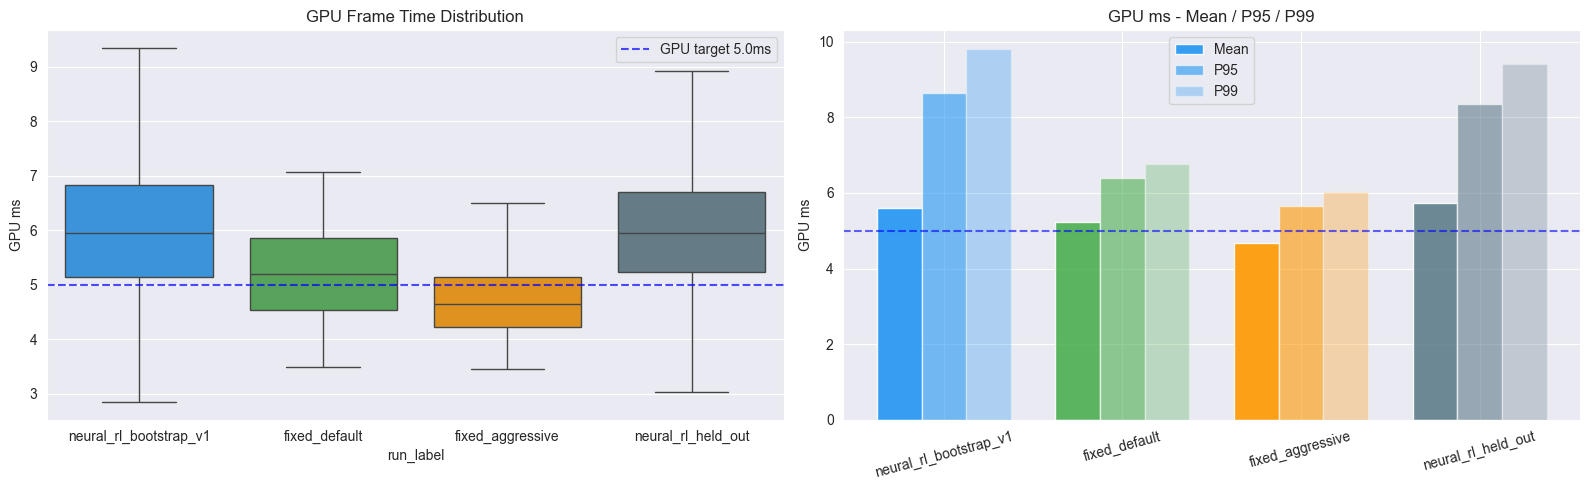

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = {r: RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs}

ax = axes[0]
sns.boxplot(data=data, x='run_label', y='gpu_ms', palette=palette,
            ax=ax, showfliers=False, order=runs)
ax.axhline(GPU_TARGET_MS, color='blue', linestyle='--', alpha=0.7,
           label=f'GPU target {GPU_TARGET_MS}ms')
ax.set_title('GPU Frame Time Distribution')
ax.set_ylabel('GPU ms')
ax.legend()

ax = axes[1]
x = np.arange(len(runs))
w = 0.25
means = [summary.loc[r, 'mean_gpu_ms'] for r in runs]
p95s = [summary.loc[r, 'p95_gpu_ms'] for r in runs]
p99s = [summary.loc[r, 'p99_gpu_ms'] for r in runs]
ax.bar(x - w, means, w, label='Mean', color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.9)
ax.bar(x, p95s, w, label='P95', color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.6)
ax.bar(x + w, p99s, w, label='P99', color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=15)
ax.axhline(GPU_TARGET_MS, color='blue', linestyle='--', alpha=0.6)
ax.set_title('GPU ms - Mean / P95 / P99')
ax.set_ylabel('GPU ms')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'gpu_comparison.png', dpi=150)
plt.show()


## 7. FPS Stability

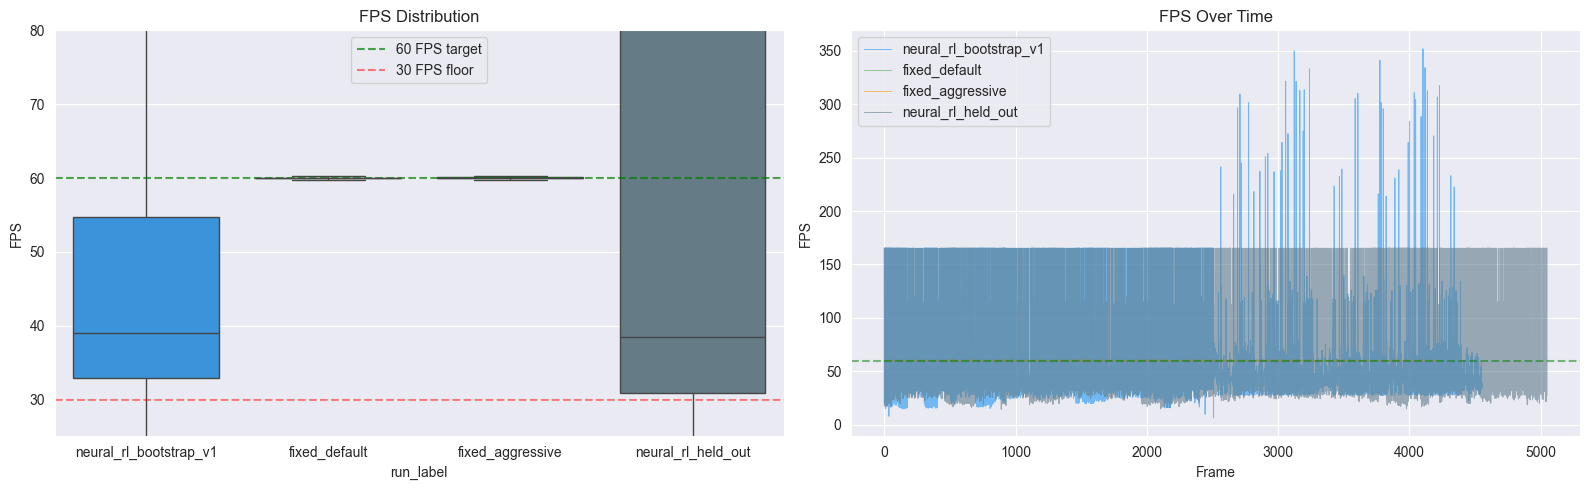

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
sns.boxplot(data=data, x='run_label', y='fps', palette=palette,
            ax=ax, showfliers=False, order=runs)

ax.set_ylim(25, 80)  # FIX: zoom into relevant FPS range

ax.axhline(60, color='green', linestyle='--', alpha=0.7, label='60 FPS target')
ax.axhline(30, color='red',   linestyle='--', alpha=0.5, label='30 FPS floor')

ax.set_title('FPS Distribution')
ax.set_ylabel('FPS')
ax.legend()

ax = axes[1]
for run in runs:
    subset = data[data['run_label'] == run].reset_index(drop=True)
    ax.plot(subset.index, subset['fps'],
            alpha=0.6, lw=0.7,
            color=RUN_COLORS.get(run, DEFAULT_COLOR), label=run)
ax.axhline(60, color='green', linestyle='--', alpha=0.5)
ax.set_title('FPS Over Time')
ax.set_xlabel('Frame')
ax.set_ylabel('FPS')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fps_comparison.png', dpi=150)
plt.show()

## 8. LOD Bias Distribution & Switch Rate

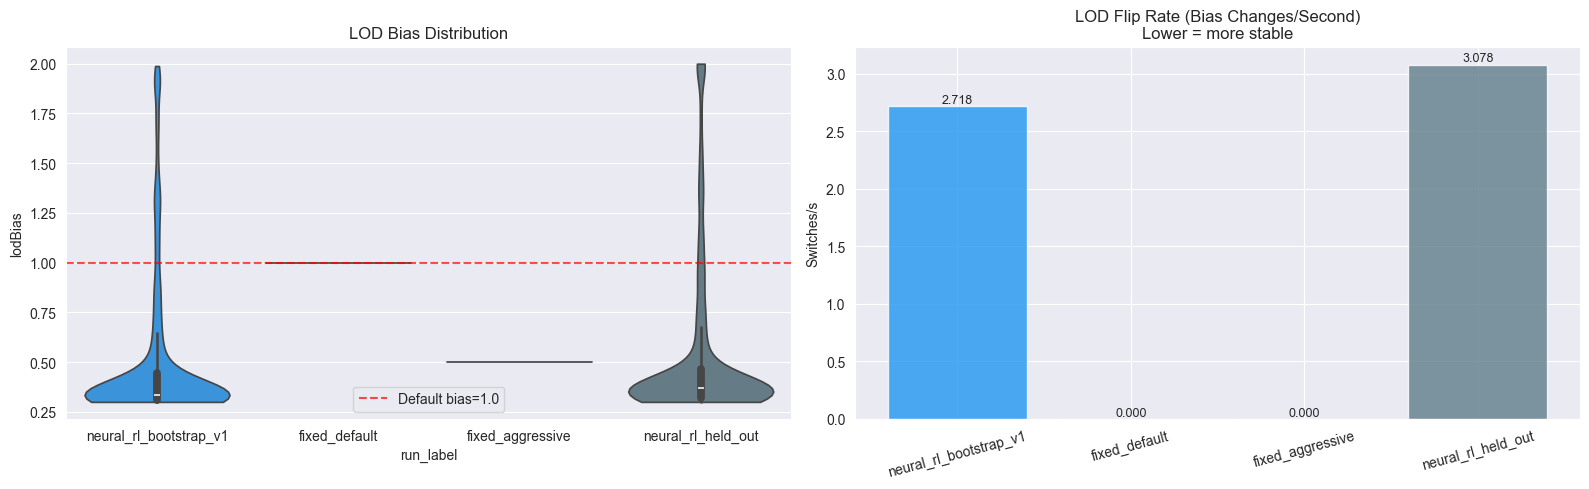


===== FPS ANALYSIS =====

RUN: neural_rl_bootstrap_v1
  mean_fps = 61.61
  p5_fps   = 21.76
  min_fps  = 6.23
  ✅ MEETS 60 FPS (avg)
  ❌ FREQUENT DROPS
  ❌ SEVERE FRAME DROPS (<30 FPS)

RUN: fixed_default
  mean_fps = 60.00
  p5_fps   = 59.73
  min_fps  = 58.04
  ✅ MEETS 60 FPS (avg)
  ✅ VERY STABLE (tight frame pacing)
  ✅ NO MAJOR STUTTER

RUN: fixed_aggressive
  mean_fps = 60.00
  p5_fps   = 59.74
  min_fps  = 58.20
  ✅ MEETS 60 FPS (avg)
  ✅ VERY STABLE (tight frame pacing)
  ✅ NO MAJOR STUTTER

RUN: neural_rl_held_out
  mean_fps = 66.39
  p5_fps   = 21.62
  min_fps  = 14.33
  ✅ MEETS 60 FPS (avg)
  ❌ FREQUENT DROPS
  ❌ SEVERE FRAME DROPS (<30 FPS)

===== FPS RANKING =====
  1. neural_rl_held_out -> 66.39 FPS
  2. neural_rl_bootstrap_v1 -> 61.61 FPS
  3. fixed_default -> 60.00 FPS
  4. fixed_aggressive -> 60.00 FPS

BEST FPS PERFORMANCE: neural_rl_held_out

===== VS FIXED DEFAULT =====
  neural_rl_bootstrap_v1: +1.61 FPS (+2.7% higher)
  fixed_default: +0.00 FPS (+0.0% lower)
  fi

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# LOD bias violin
ax = axes[0]
lod_data = data[data['lod_bias'].notna() & (data['lod_bias'] > 0)]
if len(lod_data) > 0:
    sns.violinplot(data=lod_data, x='run_label', y='lod_bias',
                   palette=palette, ax=ax, order=runs, cut=0)
ax.axhline(1.0, color='red', linestyle='--', alpha=0.7, label='Default bias=1.0')
ax.set_title('LOD Bias Distribution')
ax.set_ylabel('lodBias')
ax.legend()

# Flip rate bar
ax = axes[1]
flip_rates = [summary.loc[r, 'flip_rate_hz'] for r in runs]
colors     = [RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs]
bars = ax.bar(runs, flip_rates, color=colors, alpha=0.8, edgecolor='white')
for bar, rate in zip(bars, flip_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{rate:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_title('LOD Flip Rate (Bias Changes/Second)\nLower = more stable')
ax.set_ylabel('Switches/s')
ax.set_xticklabels(runs, rotation=15)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'lod_stability.png', dpi=150)
plt.show()

# ===== FPS PERFORMANCE SUMMARY =====
print('\n===== FPS ANALYSIS =====')

best_run = None
best_fps = -float('inf')

for run in runs:
    df = data[data['run_label'] == run]

    fps = df['fps'].dropna()
    mean_fps = fps.mean()
    p5_fps   = np.percentile(fps, 5) if len(fps) else 0
    min_fps  = fps.min() if len(fps) else 0

    print(f'\nRUN: {run}')
    print(f'  mean_fps = {mean_fps:.2f}')
    print(f'  p5_fps   = {p5_fps:.2f}')
    print(f'  min_fps  = {min_fps:.2f}')

    # ===== TARGET CHECK =====
    if mean_fps >= 60:
        print('  ✅ MEETS 60 FPS (avg)')
    else:
        print('  ❌ BELOW 60 FPS (avg)')

    # ===== STABILITY CHECK =====
    if p5_fps >= 59:
        print('  ✅ VERY STABLE (tight frame pacing)')
    elif p5_fps >= 50:
        print('  ⚠️ MINOR DROPS')
    else:
        print('  ❌ FREQUENT DROPS')

    # ===== HARD DROPS =====
    if min_fps < 30:
        print('  ❌ SEVERE FRAME DROPS (<30 FPS)')
    elif min_fps < 50:
        print('  ⚠️ NOTICEABLE STUTTER')
    else:
        print('  ✅ NO MAJOR STUTTER')

    # ===== TRACK BEST =====
    if mean_fps > best_fps:
        best_fps = mean_fps
        best_run = run


# ===== RANKING =====
print('\n===== FPS RANKING =====')

sorted_runs = sorted(runs, key=lambda r: data[data['run_label']==r]['fps'].mean(), reverse=True)

for i, run in enumerate(sorted_runs, 1):
    val = data[data['run_label']==run]['fps'].mean()
    print(f'  {i}. {run} -> {val:.2f} FPS')

print(f'\nBEST FPS PERFORMANCE: {best_run}')


# ===== VS BASELINE =====
if 'fixed_default' in runs:
    base = data[data['run_label']=='fixed_default']['fps'].mean()

    print('\n===== VS FIXED DEFAULT =====')
    for run in runs:
        val = data[data['run_label']==run]['fps'].mean()
        delta = val - base
        pct = (delta / base) * 100 if base != 0 else 0

        sign = 'higher' if delta > 0 else 'lower'
        print(f'  {run}: {delta:+.2f} FPS ({pct:+.1f}% {sign})')

## 9. CDF — GPU & CPU Frame Time

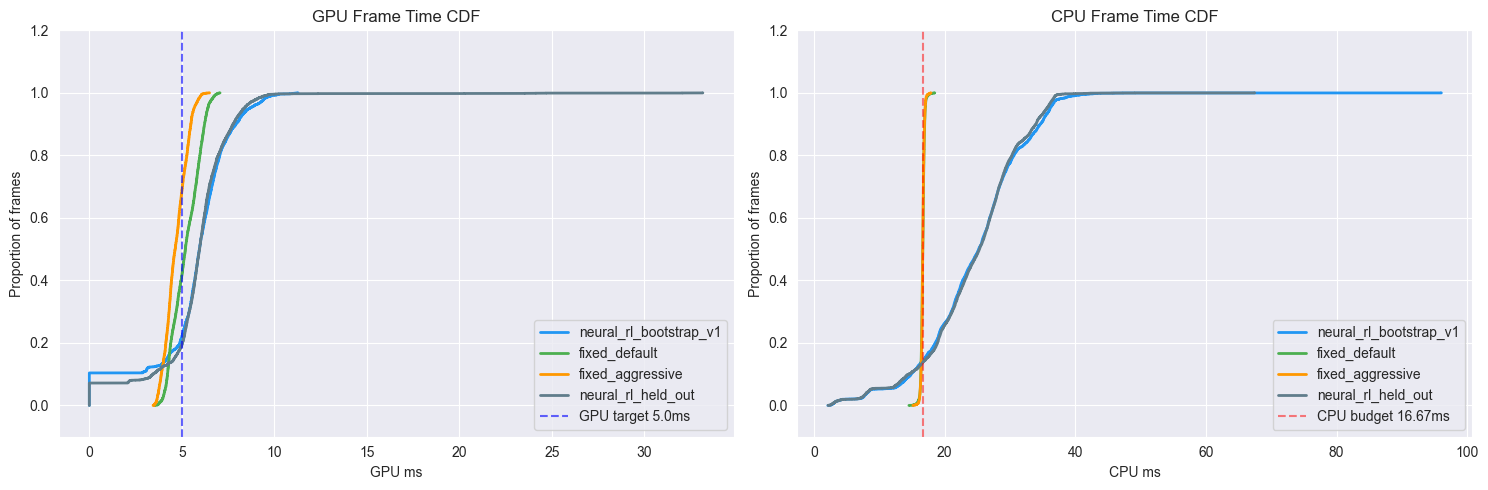

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for run in runs:
    subset = data[data['run_label'] == run]['gpu_ms'].dropna()
    sns.ecdfplot(subset, label=run, color=RUN_COLORS.get(run, DEFAULT_COLOR),
                 lw=2, ax=ax)

ax.set_ylim(-0.1, 1.2)
ax.axvline(GPU_TARGET_MS, color='blue', linestyle='--', alpha=0.6,
           label=f'GPU target {GPU_TARGET_MS}ms')
ax.set_title('GPU Frame Time CDF')
ax.set_xlabel('GPU ms')
ax.set_ylabel('Proportion of frames')
ax.legend()

ax = axes[1]
for run in runs:
    subset = data[data['run_label'] == run]['cpu_ms'].dropna()
    sns.ecdfplot(subset, label=run, color=RUN_COLORS.get(run, DEFAULT_COLOR),
                 lw=2, ax=ax)

ax.set_ylim(-0.1, 1.2)
ax.axvline(CPU_FRAME_BUDGET_MS, color='red', linestyle='--', alpha=0.5,
           label=f'CPU budget {CPU_FRAME_BUDGET_MS}ms')
ax.set_title('CPU Frame Time CDF')
ax.set_xlabel('CPU ms')
ax.set_ylabel('Proportion of frames')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'performance_cdf.png', dpi=150)
plt.show()


## 10. Generalization (RL Metric 3)
Compares GPU frame time CDF on the training camera path vs. a held-out path.  
Run `RLEvaluationLogger` with `runLabel = "neural_rl_held_out"` on different camera path nodes.  
A robust policy shows similar GPU distributions across paths.

In [14]:
print('Generalization / held-out check')
print(f'Primary model label: {MODEL_LABEL}')

held_out_label = 'neural_rl_held_out'
held_out_candidates = [r for r in runs if r not in [MODEL_LABEL, 'fixed_default', 'fixed_aggressive']]

if held_out_label in runs:
    print(f'Held-out label present: {held_out_label}')
elif held_out_candidates:
    print(f'Additional RL-style labels found: {held_out_candidates}')
    print('Interpret them carefully; the canonical held-out label is still missing.')
else:
    print(f'Blocked: no "{held_out_label}" run found in {EVAL_DIR}.')
    print('Stage 4 RL Metric 3 remains unresolved until new held-out evaluation data is recorded.')


Generalization / held-out check
Primary model label: neural_rl_bootstrap_v1
Held-out label present: neural_rl_held_out


## 11. ROI — GPU Savings vs Neural Overhead

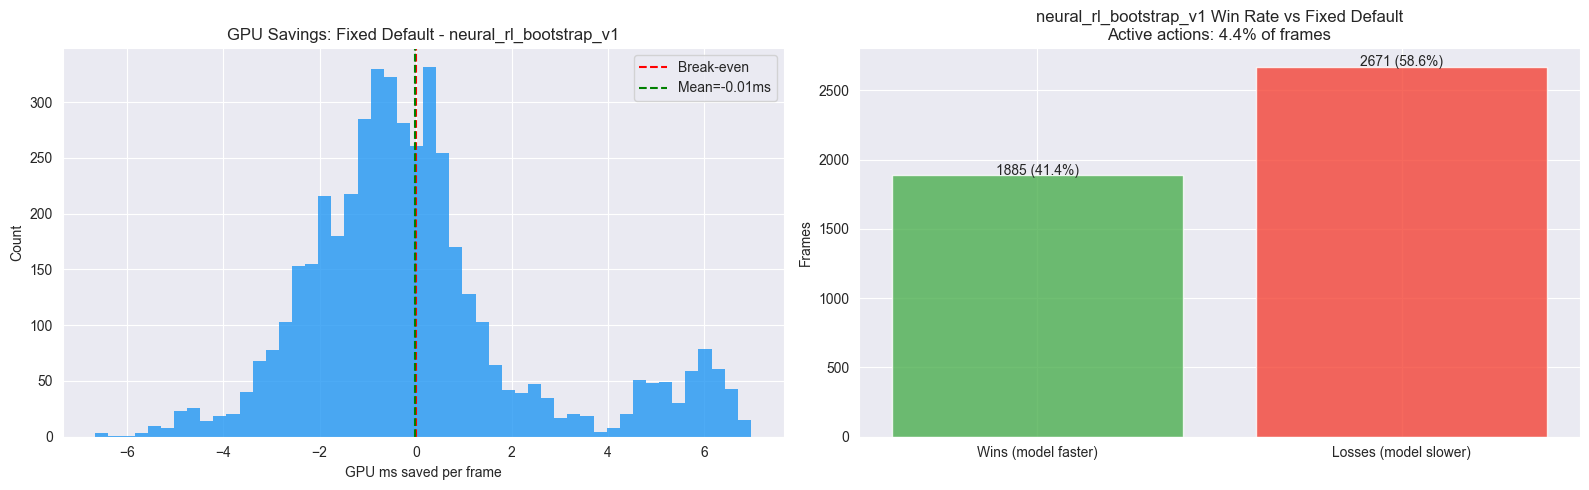

===== ROI ANALYSIS =====
MEAN SAVINGS    = -0.007 ms
MEDIAN SAVINGS  = -0.393 ms
WIN RATE        = 41.4% (1885/4556)
ACTIVE ACTION % = 4.4%


In [15]:
if MODEL_LABEL in runs and 'fixed_default' in runs:
    neural_df = data[data['run_label'] == MODEL_LABEL][['frame', 'gpu_ms']].copy()
    base_df   = data[data['run_label'] == 'fixed_default'][['frame', 'gpu_ms']].copy()

    merged = pd.merge(neural_df, base_df, on='frame', suffixes=('_neural', '_base'))
    gpu_savings = merged['gpu_ms_base'] - merged['gpu_ms_neural']

    neural_steps = data[data['run_label'] == MODEL_LABEL]
    active_pct   = 100 * (neural_steps['action_delta'].abs() > 0.001).mean()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # =========================
    # Histogram
    # =========================
    ax = axes[0]
    ax.hist(gpu_savings, bins=50, color='#2196F3', alpha=0.8, edgecolor='none')

    ax.axvline(0, color='red', linestyle='--', label='Break-even')
    ax.axvline(
        gpu_savings.mean(),
        color='green',
        linestyle='--',
        label=f'Mean={gpu_savings.mean():.2f}ms'
    )

    ax.set_title(f'GPU Savings: Fixed Default - {MODEL_LABEL}')
    ax.set_xlabel('GPU ms saved per frame')
    ax.set_ylabel('Count')
    ax.legend()

    # =========================
    # Win / Loss bar chart
    # =========================
    ax = axes[1]

    categories = ['Wins (model faster)', 'Losses (model slower)']
    counts = [
        (gpu_savings > 0).sum(),
        (gpu_savings <= 0).sum()
    ]

    ax.bar(
        categories,
        counts,
        color=['#4CAF50', '#F44336'],
        alpha=0.8,
        edgecolor='white'
    )

    for i, cnt in enumerate(counts):
        ax.text(
            i,
            cnt + 5,
            f'{cnt} ({100 * cnt / len(gpu_savings):.1f}%)',
            ha='center',
            fontsize=10
        )

    ax.set_title(
        f'{MODEL_LABEL} Win Rate vs Fixed Default\n'
        f'Active actions: {active_pct:.1f}% of frames'
    )
    ax.set_ylabel('Frames')

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'roi_analysis.png', dpi=150)
    plt.show()

else:
    print(f'ROI analysis skipped - need both "{MODEL_LABEL}" and "fixed_default" runs.')

# =========================
# Summary
# =========================
print('===== ROI ANALYSIS =====')

if MODEL_LABEL in runs and 'fixed_default' in runs:
    mean_savings   = gpu_savings.mean()
    median_savings = np.median(gpu_savings)

    wins   = (gpu_savings > 0).sum()
    losses = (gpu_savings <= 0).sum()
    total  = len(gpu_savings)

    win_rate = 100 * wins / total if total else 0

    print(f'MEAN SAVINGS    = {mean_savings:.3f} ms')
    print(f'MEDIAN SAVINGS  = {median_savings:.3f} ms')
    print(f'WIN RATE        = {win_rate:.1f}% ({wins}/{total})')
    print(f'ACTIVE ACTION % = {active_pct:.1f}%')

## 12. Final Report Table

In [16]:
import math

def frame_gpu_series(run_label):
    return data[data['run_label'] == run_label]['gpu_ms'].dropna().astype(float).reset_index(drop=True)

def episode_gpu_series(run_label):
    if ep_data is None or 'mean_gpu_ms' not in ep_data.columns:
        return pd.Series(dtype=float)
    return ep_data[ep_data['run_label'] == run_label]['mean_gpu_ms'].dropna().astype(float).reset_index(drop=True)

def select_gpu_series(run_label):
    ep_series = episode_gpu_series(run_label)
    if len(ep_series) >= 2:
        return ep_series, 'episode_mean_gpu_ms'
    return frame_gpu_series(run_label), 'frame_gpu_ms'

def comparison_gpu_series(run_a, run_b):
    a_ep = episode_gpu_series(run_a)
    b_ep = episode_gpu_series(run_b)
    if len(a_ep) >= 2 and len(b_ep) >= 2:
        return a_ep, b_ep, 'episode_mean_gpu_ms'
    return frame_gpu_series(run_a), frame_gpu_series(run_b), 'frame_gpu_ms'

try:
    from scipy import stats as scipy_stats
except Exception:
    scipy_stats = None

def mean_ci95(values):
    arr = np.asarray(pd.Series(values).dropna(), dtype=float)
    n = len(arr)
    if n == 0:
        return {
            'n': 0,
            'mean': np.nan,
            'std': np.nan,
            'ci95_low': np.nan,
            'ci95_high': np.nan,
            'method': 'none',
        }

    mean = float(arr.mean())
    std = float(arr.std(ddof=1)) if n > 1 else np.nan
    if n < 2 or not np.isfinite(std):
        return {
            'n': n,
            'mean': mean,
            'std': std,
            'ci95_low': np.nan,
            'ci95_high': np.nan,
            'method': 'insufficient_n',
        }

    se = std / math.sqrt(n)
    if scipy_stats is not None:
        crit = float(scipy_stats.t.ppf(0.975, n - 1))
        method = 'student_t'
    else:
        crit = 1.96
        method = 'normal_approx'

    margin = crit * se
    return {
        'n': n,
        'mean': mean,
        'std': std,
        'ci95_low': mean - margin,
        'ci95_high': mean + margin,
        'method': method,
    }

def welch_diff_ci(a_values, b_values):
    a = np.asarray(pd.Series(a_values).dropna(), dtype=float)
    b = np.asarray(pd.Series(b_values).dropna(), dtype=float)
    na, nb = len(a), len(b)

    if na < 2 or nb < 2:
        return {
            't_stat': np.nan,
            'df': np.nan,
            'p_value': np.nan,
            'mean_diff': np.nan,
            'ci95_low': np.nan,
            'ci95_high': np.nan,
            'method': 'insufficient_n',
        }

    mean_diff = float(a.mean() - b.mean())
    var_a = float(np.var(a, ddof=1))
    var_b = float(np.var(b, ddof=1))
    se_sq = (var_a / na) + (var_b / nb)
    if not np.isfinite(se_sq) or se_sq <= 0:
        return {
            't_stat': np.nan,
            'df': np.nan,
            'p_value': np.nan,
            'mean_diff': mean_diff,
            'ci95_low': np.nan,
            'ci95_high': np.nan,
            'method': 'degenerate_variance',
        }

    se = math.sqrt(se_sq)
    t_stat = mean_diff / se

    df_num = se_sq ** 2
    df_den = ((var_a / na) ** 2) / (na - 1) + ((var_b / nb) ** 2) / (nb - 1)
    df = float(df_num / df_den) if df_den > 0 else np.nan

    if scipy_stats is not None and np.isfinite(df):
        p_value = float(scipy_stats.ttest_ind(a, b, equal_var=False, nan_policy='omit').pvalue)
        crit = float(scipy_stats.t.ppf(0.975, df))
        method = 'welch_t'
    else:
        p_value = float(math.erfc(abs(t_stat) / math.sqrt(2.0)))
        crit = 1.96
        method = 'welch_normal_approx'

    margin = crit * se
    return {
        't_stat': float(t_stat),
        'df': df,
        'p_value': p_value,
        'mean_diff': mean_diff,
        'ci95_low': mean_diff - margin,
        'ci95_high': mean_diff + margin,
        'method': method,
    }

report_cols = [
    'frames', 'mean_cpu_ms', 'p95_cpu_ms', 'p99_cpu_ms',
    'mean_gpu_ms', 'p95_gpu_ms', 'p99_gpu_ms',
    'gpu_over_target_pct', 'cpu_over_budget_pct',
    'mean_fps', 'p5_fps',
    'mean_lod_bias', 'action_std',
    'lod_switches', 'flip_rate_hz', 'mean_screen_cov',
]
report = summary[[c for c in report_cols if c in summary.columns]]
print('=== Final Evaluation Report ===')
display(report.T)

report.to_csv(PLOTS_DIR / 'eval_summary_report.csv')
print(f'Saved: {PLOTS_DIR / "eval_summary_report.csv"}')

stat_rows = []
for baseline_label in ['fixed_default', 'fixed_aggressive']:
    if MODEL_LABEL not in runs or baseline_label not in runs:
        continue

    model_preferred, model_preferred_unit = select_gpu_series(MODEL_LABEL)
    baseline_preferred, baseline_preferred_unit = select_gpu_series(baseline_label)
    model_series, baseline_series, comparison_unit = comparison_gpu_series(MODEL_LABEL, baseline_label)

    model_stats = mean_ci95(model_series)
    baseline_stats = mean_ci95(baseline_series)
    diff_stats = welch_diff_ci(model_series, baseline_series)

    note = 'Episode means used.'
    if comparison_unit == 'frame_gpu_ms':
        note = 'Frame-level fallback because both runs do not have >=2 episode means; p-values are optimistic due to temporal correlation.'

    stat_rows.append({
        'comparison': f'{MODEL_LABEL} vs {baseline_label}',
        'comparison_unit': comparison_unit,
        'model_preferred_unit': model_preferred_unit,
        'baseline_preferred_unit': baseline_preferred_unit,
        'model_n': model_stats['n'],
        'baseline_n': baseline_stats['n'],
        'model_mean_gpu_ms': model_stats['mean'],
        'model_ci95_low_ms': model_stats['ci95_low'],
        'model_ci95_high_ms': model_stats['ci95_high'],
        'baseline_mean_gpu_ms': baseline_stats['mean'],
        'baseline_ci95_low_ms': baseline_stats['ci95_low'],
        'baseline_ci95_high_ms': baseline_stats['ci95_high'],
        'mean_diff_ms': diff_stats['mean_diff'],
        'diff_ci95_low_ms': diff_stats['ci95_low'],
        'diff_ci95_high_ms': diff_stats['ci95_high'],
        'welch_t': diff_stats['t_stat'],
        'welch_df': diff_stats['df'],
        'p_value': diff_stats['p_value'],
        'test_method': diff_stats['method'],
        'note': note,
    })

if stat_rows:
    stat_df = pd.DataFrame(stat_rows)
    print('\n=== Statistical Comparison (GPU mean) ===')
    display(stat_df)
    stat_df.to_csv(PLOTS_DIR / 'eval_statistical_tests.csv', index=False)
    print(f'Saved: {PLOTS_DIR / "eval_statistical_tests.csv"}')
else:
    print('\nStatistical comparison skipped: need the bootstrap model label plus at least one fixed baseline.')

legacy_baselines = sorted(data.loc[data['source'] == 'baseline', 'run_label'].unique().tolist())
if legacy_baselines:
    print('\nBaseline provenance note:')
    print(
        '  The following runs come from legacy baseline files, not RLEvaluationLogger-matched recollection: '
        + ', '.join(legacy_baselines)
    )
    print('  Treat their comparisons as provisional until they are re-recorded on identical paths.')


=== Final Evaluation Report ===


run_label,neural_rl_bootstrap_v1,fixed_default,fixed_aggressive,neural_rl_held_out
frames,4556.0000,3914.000,4225.000,5048.0000
mean_cpu_ms,24.5090,16.666,16.666,24.3780
p95_cpu_ms,36.1510,17.048,17.032,35.6090
p99_cpu_ms,39.4980,17.390,17.250,36.9260
mean_gpu_ms,5.6070,5.218,4.683,5.7250
p95_gpu_ms,8.6300,6.402,5.657,8.3570
p99_gpu_ms,9.8080,6.761,6.021,9.4150
gpu_over_target_pct,78.1000,58.500,31.600,80.7000
cpu_over_budget_pct,85.5000,49.800,49.100,86.2000
mean_fps,61.6100,60.000,60.000,66.3900


Saved: C:\Users\Gica\neural-lod\ml_pipeline\plots\Stage_4\Eval\eval_summary_report.csv

=== Statistical Comparison (GPU mean) ===


,comparison,comparison_unit,model_preferred_unit,baseline_preferred_unit,model_n,baseline_n,model_mean_gpu_ms,model_ci95_low_ms,model_ci95_high_ms,baseline_mean_gpu_ms,baseline_ci95_low_ms,baseline_ci95_high_ms,mean_diff_ms,diff_ci95_low_ms,diff_ci95_high_ms,welch_t,welch_df,p_value,test_method,note
0,neural_rl_bootstrap_v1 vs fixed_default,frame_gpu_ms,episode_mean_gpu_ms,frame_gpu_ms,4556,3914,5.607202,5.540664,5.67374,5.217729,5.193848,5.241610,0.389473,0.318784,0.460163,10.800968,5694.007812,6.203607e-27,welch_t,Frame-level fallback because both runs do not ...
1,neural_rl_bootstrap_v1 vs fixed_aggressive,frame_gpu_ms,episode_mean_gpu_ms,frame_gpu_ms,4556,4225,5.607202,5.540664,5.67374,4.683082,4.665107,4.701057,0.924120,0.855200,0.993041,26.286223,5214.100233,4.070240e-143,welch_t,Frame-level fallback because both runs do not ...


Saved: C:\Users\Gica\neural-lod\ml_pipeline\plots\Stage_4\Eval\eval_statistical_tests.csv

Baseline provenance note:
  The following runs come from legacy baseline files, not RLEvaluationLogger-matched recollection: fixed_aggressive, fixed_default
  Treat their comparisons as provisional until they are re-recorded on identical paths.


## 11. Train vs Eval Rollout Context
Compare rule-based training rollouts against model-based evaluation rollouts to see how the learned bootstrap policy shifts action usage, GPU time, and bias behavior.


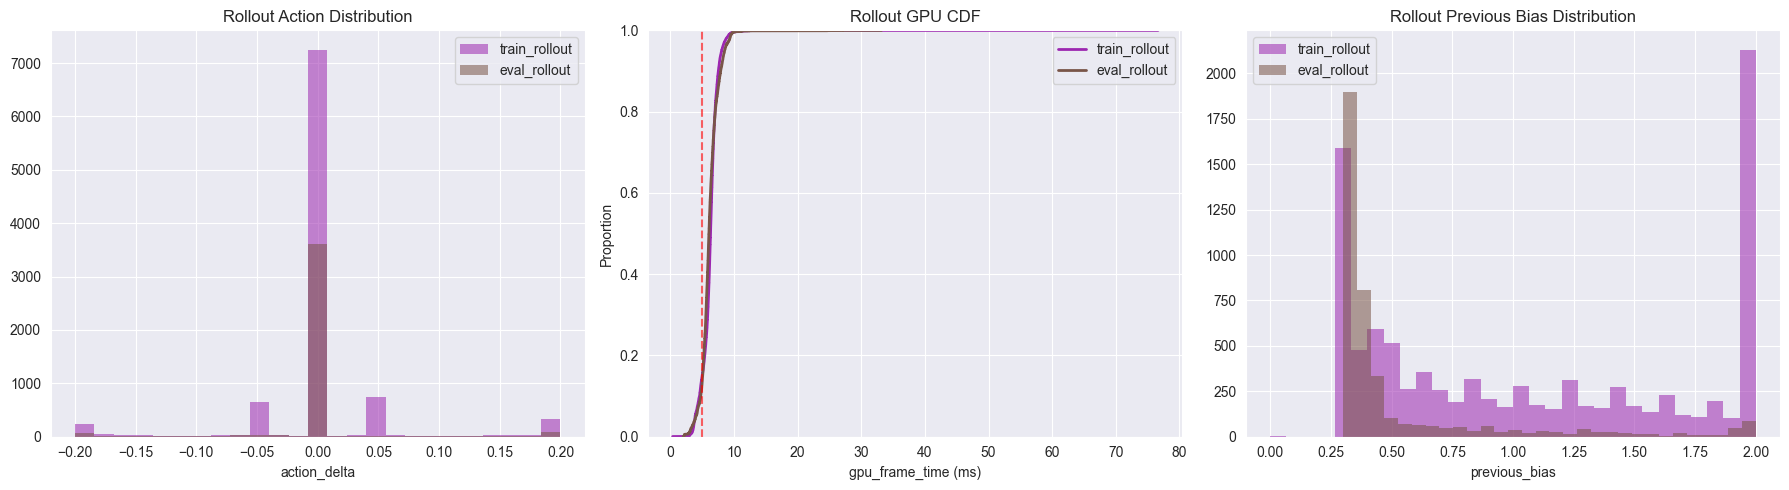

,rows,mean_gpu_ms,mean_fps,mean_previous_bias,nonzero_action_pct,mean_switch_count
source,,,,,,
eval_rollout,3995,6.1754,69.9882,0.5214,9.59,1.3204
train_rollout,9626,6.2179,54.2331,1.0745,24.66,3.3512


In [17]:
train_rollout_files = list(TRAIN_ROLLOUT_DIR.glob('rollout_ep*.csv'))
eval_rollout_files  = list(EVAL_ROLLOUT_DIR.glob('rollout_ep*.csv'))

rollout_parts = []
for label, files in [('train_rollout', train_rollout_files), ('eval_rollout', eval_rollout_files)]:
    for f in files:
        df = pd.read_csv(f)
        df['rollout_source'] = label
        rollout_parts.append(df)

if not rollout_parts:
    print('No rollout CSVs found for rollout-context comparison.')
else:
    roll = pd.concat(rollout_parts, ignore_index=True)
    for col in ['gpu_frame_time', 'cpu_frame_time', 'fps', 'previous_bias', 'action_delta', 'recent_lod_switch_count']:
        if col in roll.columns:
            roll[col] = pd.to_numeric(roll[col], errors='coerce')
    roll = roll.dropna(subset=['gpu_frame_time', 'fps', 'action_delta'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    for src in ['train_rollout', 'eval_rollout']:
        subset = roll[roll['rollout_source'] == src]['action_delta']
        if len(subset):
            ax.hist(subset, bins=25, alpha=0.55, label=src,
                    color=RUN_COLORS.get(src, DEFAULT_COLOR), edgecolor='none')
    ax.set_title('Rollout Action Distribution')
    ax.set_xlabel('action_delta')
    ax.legend()

    ax = axes[1]
    for src in ['train_rollout', 'eval_rollout']:
        subset = roll[roll['rollout_source'] == src]['gpu_frame_time']
        if len(subset):
            sns.ecdfplot(subset, ax=ax, label=src, color=RUN_COLORS.get(src, DEFAULT_COLOR), lw=2)
    ax.axvline(T_TARGET_MS, color='red', linestyle='--', alpha=0.6)
    ax.set_title('Rollout GPU CDF')
    ax.set_xlabel('gpu_frame_time (ms)')
    ax.legend()

    ax = axes[2]
    for src in ['train_rollout', 'eval_rollout']:
        subset = roll[roll['rollout_source'] == src]['previous_bias']
        if len(subset):
            ax.hist(subset, bins=30, alpha=0.55, label=src,
                    color=RUN_COLORS.get(src, DEFAULT_COLOR), edgecolor='none')
    ax.set_title('Rollout Previous Bias Distribution')
    ax.set_xlabel('previous_bias')
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'rollout_context_comparison.png', dpi=150)
    plt.show()

    rows = []
    for src in sorted(roll['rollout_source'].unique()):
        subset = roll[roll['rollout_source'] == src]
        rows.append({
            'source': src,
            'rows': len(subset),
            'mean_gpu_ms': round(subset['gpu_frame_time'].mean(), 4),
            'mean_fps': round(subset['fps'].mean(), 4),
            'mean_previous_bias': round(subset['previous_bias'].mean(), 4),
            'nonzero_action_pct': round((subset['action_delta'].abs() > 1e-6).mean() * 100, 2),
            'mean_switch_count': round(subset['recent_lod_switch_count'].mean(), 4),
        })
    rollout_summary = pd.DataFrame(rows).set_index('source')
    display(rollout_summary)
